In [75]:
import sys
sys.path.insert(0, '..')

In [76]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'



In [77]:
names = [
    'SM1', 'SM2\nNICMOS installed', 'SM3A', 'SM3B\nCryocooler Installed', 'SM4', 
    'NICMOS cryogen exhausted', 'Cryocooler Fails',
    "GTO 7232", "", "GO 11117", "", "", "", "", "GO 9737", "GO 10143", "GO 9749", ""
    ]

dates = [
    '1993-12-7', '1997-2-14', '1999-12-23', '2002-3-8', '2009-5-17',
    '1999-11-15', '2008-9-11',
    '1997-07-03', '1998-05-01', '2008-04-15', '2008-05-03', '2008-05-18', '2008-05-28', '2008-08-11', "2003-11-04", "2005-05-16", "2003-12-23", "2004-02-14"
    ]

# Convert date strings (e.g. 2014-10-18) to datetime
dates = [datetime.strptime(d, "%Y-%m-%d") for d in dates]

In [78]:
len(levels)

18

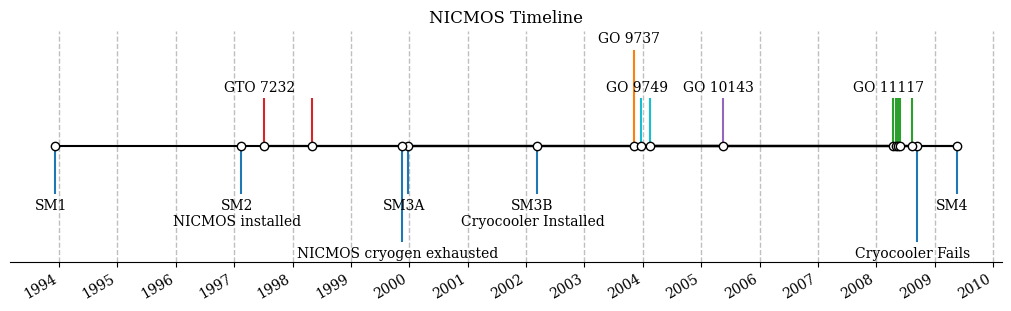

In [79]:
# Choose some nice levels
levels = np.tile([-5, 5, -3, 3, -1, 1],
                 int(np.ceil(len(dates)/6)))[:len(dates)]

levels = [-1]*5 + [-2, -2] + [1]*7 + [2,1,1,1]

# Create figure and plot a stem plot with the date
# fig, ax = plt.subplots(figsize=(8.8, 4), constrained_layout=True)
fig, ax = plt.subplots(figsize=(10, 3), constrained_layout=True)

ax.set(title="NICMOS Timeline")

ax.vlines(dates[:7], 0, levels[:7], color="tab:blue")  # The vertical stems.

ax.vlines(dates[7:9], 0, levels[7:9], color="tab:red")  # The vertical stems.

ax.vlines(dates[9:14], 0, levels[9:14], color="tab:green")  # The vertical stems.

ax.vlines(dates[14:15], 0, levels[14:15], color="tab:orange")  # The vertical stems.

ax.vlines(dates[15:16], 0, levels[15:16], color="tab:purple")  # The vertical stems.

ax.vlines(dates[16:18], 0, levels[16:18], color="tab:cyan")  # The vertical stems.


ax.plot(dates, np.zeros_like(dates), "-o",
        color="k", markerfacecolor="w")  # Baseline and markers on it.

# annotate lines
for d, l, r in zip(dates, levels, names):
    ax.annotate(r, xy=(d, l),
                xytext=(-3, np.sign(l)*3), textcoords="offset points",
                horizontalalignment="center",
                verticalalignment="bottom" if l > 0 else "top")

# format xaxis with 4 month intervals
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

# remove y axis and spines
ax.yaxis.set_visible(False)
ax.spines[["left", "top", "right"]].set_visible(False)
ax.set_axisbelow(True) 

ax.grid(True, color='gray', linestyle='--', linewidth=1, alpha=0.5)

ax.margins(y=0.1)
plt.show()
fig.savefig("timeline.pdf")